# **LSTM (Long short-term memory) neural network para la predicción a corto plazo del flujo de pasajeros en la red metro de Medellín.**

Este proyecto busca predecir el flujo de pasajeros en la red Metro de Medellín, Antioquia. Para esto se utilizan herramientas como PyTorch para construir una red neuronal LSTM, buscando patrones clave para la detección de características de comportamientos que permitan mejorar el rendimiento y operacionalidad de las redes metro, además de brindar ideas relevantes para la resolución de problemas.

Universidad Pontificia Bolivariana - Roy Sandoval

# Importando librerías

In [ ]:
!pip install cudf-cu11 --extra-index-url=https://pypi.ngc.nvidia.com
!rm -rf /usr/local/lib/python3.8/dist-packages/cupy*
!pip install cupy-cuda11x

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of cudf-cu11 to determine which version is compatible with other requirements. This could take a while.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import cudf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import numpy as np
from scipy.stats import shapiro, levene
import statsmodels.api as sm
from statsmodels.formula.api import ols
from ipywidgets import interact, interact_manual, Dropdown
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import Dataset, DataLoader
import datetime

ERROR:ptxcompiler.patch:Error getting driver and runtime versions:

stdout:



stderr:

Traceback (most recent call last):
  File "<string>", line 4, in <module>
  File "/usr/local/lib/python3.10/dist-packages/numba/cuda/cudadrv/driver.py", line 295, in __getattr__
    raise CudaSupportError("Error at driver init: \n%s:" %
numba.cuda.cudadrv.error.CudaSupportError: Error at driver init: 

CUDA driver library cannot be found.
If you are sure that a CUDA driver is installed,
try setting environment variable NUMBA_CUDA_DRIVER
with the file path of the CUDA driver shared library.
:


Not patching Numba
/usr/local/lib/python3.10/dist-packages/cudf/utils/gpu_utils.py:62: UserWarning: Failed to dlopen libcuda.so.1
  warnings.warn(str(e))
/usr/local/lib/python3.10/dist-packages/cupy/_environment.py:540: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environm

In [ ]:
!pip install holidays_co

In [ ]:
from holidays_co import get_colombia_holidays_by_year
holidays = get_colombia_holidays_by_year(2024)
print(holidays)

[Holiday(date=datetime.date(2024, 1, 1), celebration='Año Nuevo'), Holiday(date=datetime.date(2024, 1, 8), celebration='Día de los Reyes Magos'), Holiday(date=datetime.date(2024, 3, 25), celebration='Día de San José'), Holiday(date=datetime.date(2024, 3, 28), celebration='Jueves Santo'), Holiday(date=datetime.date(2024, 3, 29), celebration='Viernes Santo'), Holiday(date=datetime.date(2024, 5, 1), celebration='Día del Trabajo'), Holiday(date=datetime.date(2024, 5, 13), celebration='Ascensión del Señor'), Holiday(date=datetime.date(2024, 6, 3), celebration='Corphus Christi'), Holiday(date=datetime.date(2024, 6, 10), celebration='Sagrado Corazón de Jesús'), Holiday(date=datetime.date(2024, 7, 1), celebration='San Pedro y San Pablo'), Holiday(date=datetime.date(2024, 7, 20), celebration='Día de la Independencia'), Holiday(date=datetime.date(2024, 8, 7), celebration='Batalla de Boyacá'), Holiday(date=datetime.date(2024, 8, 19), celebration='La Asunción de la Virgen'), Holiday(date=datetime.

In [ ]:
from holidays_co import is_holiday_date

date = datetime.date(2024,5,13) #Lunes festivo 13 de mayo 2024 como ejemplo (Dia de la Ascencion)

print(date)
is_holiday_date(date)

2024-05-13


True

#Cargando datos


In [ ]:
print('Descargando archivos...')
!curl -L "https://drive.google.com/uc?id=14o-Mf5BBimP4clt97ytIKvC3FwY3Mpci&export=download" -o Afluencia2024.xlsx
!curl -L "https://drive.google.com/uc?id=1rawKGyqGLCjhYsE1oePv499lQdawN3zX&export=download" -o Afluencia2023.xlsx
!curl -L "https://drive.google.com/uc?id=11VeQzlInoljZKKil7kPcWjwvESCZbMSv&export=download" -o Afluencia2022.xlsx
!curl -L "https://drive.google.com/uc?id=1zWP6FHA6aTJJ58xy119k5tAQRxI3DEIF&export=download" -o Afluencia2021.xlsx
!curl -L "https://drive.google.com/uc?id=1klQ3qzRFX2-jpkc4Nh8wLIo6weFKQ6Pa&export=download" -o Afluencia2020.xlsx
!curl -L "https://drive.google.com/uc?id=1PsQvhT1bt6-xr5vG1Xi95aHBg2anYI51&export=download" -o Afluencia2019.xlsx
#https://raw.githubusercontent.com/Rosvend/Passenger-flow-prediction-LSTM/main/Datasets/Afluencia_2019.xlsx

Descargando archivos...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  313k  100  313k    0     0  94026      0  0:00:03  0:00:03 --:--:--  164k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  659k  100  659k    0     0   188k      0  0:00:03  0:00:03 --:--:--  321k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  648k  100  648k    0     0   175k      0  0:00:03  0:00:03 --:--:--  331k
  % Total    % Received % Xf

In [ ]:
df2019 = pd.read_excel('/content/Afluencia2019.xlsx',engine='openpyxl')
df2020 = pd.read_excel('/content/Afluencia2020.xlsx',engine='openpyxl')
df2021 = pd.read_excel('/content/Afluencia2021.xlsx',engine='openpyxl')
df2022 = pd.read_excel('/content/Afluencia2022.xlsx',engine='openpyxl')
df2023 = pd.read_excel('/content/Afluencia2023.xlsx',engine='openpyxl')
df2024 = pd.read_excel('/content/Afluencia2024.xlsx',engine='openpyxl')
df2023.head(13) #Imprimos las 12 lineas del metro

,Día,Línea de Servicio,Hora de operación,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,NaN,NaN,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
1,01/01/2023,LÍNEA 1,192,811,896,716,673,922,1023,1208,...,1629,1985,2361,2694,2303,1839,1478,236,NaN,25483
2,01/01/2023,LÍNEA 2,11,123,116,95,102,144,147,189,...,191,255,280,317,252,164,111,7,NaN,3210
3,01/01/2023,LÍNEA A,1328,5104,5701,4309,4054,4852,5880,7629,...,10999,13027,15965,19123,15663,12918,9509,819,NaN,166047
4,01/01/2024,LÍNEA B,221,701,750,655,628,863,1085,1228,...,1930,2247,2498,2648,2029,1472,1087,151,NaN,25106
5,01/01/2023,LÍNEA H,NaN,NaN,NaN,NaN,NaN,56,62,49,...,55,128,99,109,68,46,27,1,NaN,970
6,01/01/2023,LÍNEA J,NaN,NaN,NaN,NaN,NaN,470,410,490,...,688,710,857,933,651,311,146,3,NaN,7209
7,01/01/2023,LÍNEA K,NaN,NaN,NaN,NaN,350,555,630,745,...,1432,1515,1788,1562,1110,766,329,4,NaN,13664
8,01/01/2023,LÍNEA L,NaN,NaN,NaN,NaN,11,61,158,364,...,617,531,428,NaN,NaN,NaN,NaN,NaN,NaN,4113
9,01/01/2023,LÍNEA M,NaN,NaN,NaN,NaN,1,156,123,176,...,229,332,319,411,408,260,240,92,NaN,3425


# Proceso de calidad de datos

In [ ]:
df2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3565 entries, 0 to 3564
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   3564 non-null   object
 1   Unnamed: 1   3564 non-null   object
 2   Unnamed: 2   2937 non-null   object
 3   Unnamed: 3   2958 non-null   object
 4   Unnamed: 4   2960 non-null   object
 5   Unnamed: 5   2989 non-null   object
 6   Unnamed: 6   3426 non-null   object
 7   Unnamed: 7   3501 non-null   object
 8   Unnamed: 8   3499 non-null   object
 9   Unnamed: 9   3517 non-null   object
 10  Unnamed: 10  3513 non-null   object
 11  Unnamed: 11  3515 non-null   object
 12  Unnamed: 12  3524 non-null   object
 13  Unnamed: 13  3517 non-null   object
 14  Unnamed: 14  3525 non-null   object
 15  Unnamed: 15  3536 non-null   object
 16  Unnamed: 16  3361 non-null   object
 17  Unnamed: 17  3226 non-null   object
 18  Unnamed: 18  3230 non-null   object
 19  Unnamed: 19  3228 non-null 

In [ ]:
df2019.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,Día,Línea de servicio,Hora de operación,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
2,2019-01-01 00:00:00,Línea 1,12,826,1134,987,884,975,1259,1348,...,2085,2230,2636,2884,2603,2024,1257,271,5,28850
3,2019-01-02 00:00:00,Línea 1,1716,4498,6629,6284,4145,3784,3746,3854,...,4709,5750,7517,6661,4307,2975,2709,1890,135,83484
4,2019-01-03 00:00:00,Línea 1,1860,4869,7587,7088,4483,4486,4126,4136,...,5061,6093,8023,7034,4481,3244,2905,1739,124,90472


In [ ]:
hour = 4
for i in range(2, 22):
    if hour < 12:
        new_column_name = f"{hour}AM"
    elif hour == 12:
        new_column_name = "12PM"
    elif hour>12:
        new_column_name = f"{hour-12}PM"

    df2019 = df2019.rename(columns={f"Unnamed: {i}": new_column_name})
    hour += 1

df2019.columns.to_list()

['Unnamed: 0',
 'Unnamed: 1',
 '4AM',
 '5AM',
 '6AM',
 '7AM',
 '8AM',
 '9AM',
 '10AM',
 '11AM',
 '12PM',
 '1PM',
 '2PM',
 '3PM',
 '4PM',
 '5PM',
 '6PM',
 '7PM',
 '8PM',
 '9PM',
 '10PM',
 '11PM',
 'Unnamed: 22']

In [ ]:
df2019 = df2019.rename(columns={'Unnamed: 0':'Dia','Unnamed: 1':'Linea','Hora de operación':'4AM','Unnamed: 22':'Total_pasajeros'}) #Cambiamos el resto de columnas que faltaron
df2019 = df2019.drop([0,1])
df2019.head()

,Dia,Linea,4AM,5AM,6AM,7AM,8AM,9AM,10AM,11AM,...,3PM,4PM,5PM,6PM,7PM,8PM,9PM,10PM,11PM,Total_pasajeros
2,2019-01-01 00:00:00,Línea 1,12,826,1134,987,884,975,1259,1348,...,2085,2230,2636,2884,2603,2024,1257,271,5,28850
3,2019-01-02 00:00:00,Línea 1,1716,4498,6629,6284,4145,3784,3746,3854,...,4709,5750,7517,6661,4307,2975,2709,1890,135,83484
4,2019-01-03 00:00:00,Línea 1,1860,4869,7587,7088,4483,4486,4126,4136,...,5061,6093,8023,7034,4481,3244,2905,1739,124,90472
5,2019-01-04 00:00:00,Línea 1,1845,4989,7723,7281,4857,4583,4269,4217,...,5280,6056,7992,7081,4805,3466,3075,1900,176,93067
6,2019-01-05 00:00:00,Línea 1,1550,3852,4898,5221,4016,3815,3704,4048,...,4696,4528,4106,4377,3842,2973,2866,1983,167,75451


In [ ]:
df2020.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,Día,Línea de servicio,Hora de operación,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
2,2020-01-01 00:00:00,Línea 1,NaN,902,1126,881,743,924,1137,1299,...,2056,2374,2727,2908,2978,2457,1369,174,NaN,29341
3,2020-01-01 00:00:00,Línea 2,NaN,63,94,66,68,61,79,127,...,169,188,287,302,236,188,85,16,NaN,2435
4,2020-01-01 00:00:00,Línea A,1,4901,6168,4822,4158,5152,6467,8488,...,12785,15911,19522,20582,20358,16450,10701,1177,NaN,192714


In [ ]:
hour = 4
for i in range(2, 22):
    if hour < 12:
        new_column_name = f"{hour}AM"
    elif hour == 12:
        new_column_name = "12PM"
    elif hour>12:
        new_column_name = f"{hour-12}PM"

    df2020 = df2020.rename(columns={f"Unnamed: {i}": new_column_name})
    hour += 1

df2020.columns.to_list()

['Unnamed: 0',
 'Unnamed: 1',
 '4AM',
 '5AM',
 '6AM',
 '7AM',
 '8AM',
 '9AM',
 '10AM',
 '11AM',
 '12PM',
 '1PM',
 '2PM',
 '3PM',
 '4PM',
 '5PM',
 '6PM',
 '7PM',
 '8PM',
 '9PM',
 '10PM',
 '11PM',
 'Unnamed: 22']

In [ ]:
df2020 = df2020.rename(columns={'Unnamed: 0':'Dia','Unnamed: 1':'Linea','Hora de operación':'4AM','Unnamed: 22':'Total_pasajeros'}) #Cambiamos el resto de columnas que faltaron
df2020 = df2020.drop([0,1])
df2020.head()

,Dia,Linea,4AM,5AM,6AM,7AM,8AM,9AM,10AM,11AM,...,3PM,4PM,5PM,6PM,7PM,8PM,9PM,10PM,11PM,Total_pasajeros
2,2020-01-01 00:00:00,Línea 1,NaN,902,1126,881,743,924,1137,1299,...,2056,2374,2727,2908,2978,2457,1369,174,NaN,29341
3,2020-01-01 00:00:00,Línea 2,NaN,63,94,66,68,61,79,127,...,169,188,287,302,236,188,85,16,NaN,2435
4,2020-01-01 00:00:00,Línea A,1,4901,6168,4822,4158,5152,6467,8488,...,12785,15911,19522,20582,20358,16450,10701,1177,NaN,192714
5,2020-01-01 00:00:00,Línea B,NaN,750,863,674,693,891,1161,1600,...,2140,2775,2942,3083,2319,1738,725,39,NaN,28691
6,2020-01-01 00:00:00,Línea H,NaN,NaN,NaN,NaN,1,39,60,65,...,66,130,105,136,121,49,14,2,NaN,1030


In [ ]:
df2021.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,Día,Línea de servicio,Hora de operación,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
2,2021-01-01 00:00:00,LÍNEA A,NaN,3487,3405,2011,1148,974,888,1011,...,1833,2900,3269,3314,2273,1329,12,NaN,NaN,31911
3,2021-01-01 00:00:00,LÍNEA B,NaN,532,438,267,164,145,135,142,...,212,321,421,432,215,157,NaN,NaN,NaN,4050
4,2021-01-01 00:00:00,LÍNEA K,NaN,NaN,NaN,NaN,40,131,104,156,...,167,258,189,122,103,38,NaN,NaN,NaN,1714


In [ ]:
hour = 4
for i in range(2, 22):
    if hour < 12:
        new_column_name = f"{hour}AM"
    elif hour == 12:
        new_column_name = "12PM"
    elif hour>12:
        new_column_name = f"{hour-12}PM"

    df2021 = df2021.rename(columns={f"Unnamed: {i}": new_column_name})
    hour += 1

df2021.columns.to_list()

['Unnamed: 0',
 'Unnamed: 1',
 '4AM',
 '5AM',
 '6AM',
 '7AM',
 '8AM',
 '9AM',
 '10AM',
 '11AM',
 '12PM',
 '1PM',
 '2PM',
 '3PM',
 '4PM',
 '5PM',
 '6PM',
 '7PM',
 '8PM',
 '9PM',
 '10PM',
 '11PM',
 'Unnamed: 22']

In [ ]:
df2021 = df2021.rename(columns={'Unnamed: 0':'Dia','Unnamed: 1':'Linea','Hora de operación':'4AM','Unnamed: 22':'Total_pasajeros'}) #Cambiamos el resto de columnas que faltaron
df2021 = df2021.drop([0,1])
df2021.head()

,Dia,Linea,4AM,5AM,6AM,7AM,8AM,9AM,10AM,11AM,...,3PM,4PM,5PM,6PM,7PM,8PM,9PM,10PM,11PM,Total_pasajeros
2,2021-01-01 00:00:00,LÍNEA A,NaN,3487,3405,2011,1148,974,888,1011,...,1833,2900,3269,3314,2273,1329,12,NaN,NaN,31911
3,2021-01-01 00:00:00,LÍNEA B,NaN,532,438,267,164,145,135,142,...,212,321,421,432,215,157,NaN,NaN,NaN,4050
4,2021-01-01 00:00:00,LÍNEA K,NaN,NaN,NaN,NaN,40,131,104,156,...,167,258,189,122,103,38,NaN,NaN,NaN,1714
5,2021-01-01 00:00:00,LÍNEA J,NaN,NaN,NaN,NaN,1,77,74,92,...,146,179,132,135,69,42,3,NaN,NaN,1256
6,2021-01-01 00:00:00,LÍNEA 1,NaN,614,590,355,240,217,198,231,...,394,579,624,574,399,231,17,NaN,NaN,6104


In [ ]:
df2021['Dia'] = pd.to_datetime(df2021['Dia'], format='%d/%m/%Y', errors='coerce')
df2021.head()

,Dia,Linea,4AM,5AM,6AM,7AM,8AM,9AM,10AM,11AM,...,3PM,4PM,5PM,6PM,7PM,8PM,9PM,10PM,11PM,Total_pasajeros
2,2021-01-01,LÍNEA A,NaN,3487,3405,2011,1148,974,888,1011,...,1833,2900,3269,3314,2273,1329,12,NaN,NaN,31911
3,2021-01-01,LÍNEA B,NaN,532,438,267,164,145,135,142,...,212,321,421,432,215,157,NaN,NaN,NaN,4050
4,2021-01-01,LÍNEA K,NaN,NaN,NaN,NaN,40,131,104,156,...,167,258,189,122,103,38,NaN,NaN,NaN,1714
5,2021-01-01,LÍNEA J,NaN,NaN,NaN,NaN,1,77,74,92,...,146,179,132,135,69,42,3,NaN,NaN,1256
6,2021-01-01,LÍNEA 1,NaN,614,590,355,240,217,198,231,...,394,579,624,574,399,231,17,NaN,NaN,6104


In [ ]:
df2022.head()

,Día,Línea de Servicio,Hora de operación,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,NaT,NaN,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
1,2022-01-01,LÍNEA 1,165,811,854,662,589,731,836,1091,...,1479,1616,1696,1911,1611,1319,923,132,NaN,20279
2,2022-01-01,LÍNEA 2,14,90,100,81,68,95,93,90,...,168,212,213,222,169,118,71,8,NaN,2265
3,2022-01-01,LÍNEA A,1098,4363,5114,3988,3385,4033,4890,6163,...,9089,10642,11322,12716,10610,8085,6333,476,NaN,126692
4,2022-01-01,LÍNEA B,195,674,767,555,565,667,921,1246,...,1599,2121,2114,2204,1526,1028,620,58,NaN,21301


In [ ]:
hour = 4
for i in range(2, 22):
    if hour < 12:
        new_column_name = f"{hour}AM"
    elif hour == 12:
        new_column_name = "12PM"
    elif hour>12:
        new_column_name = f"{hour-12}PM"

    df2022 = df2022.rename(columns={f"Unnamed: {i}": new_column_name})
    hour += 1

df2022.columns.to_list()

['Día',
 'Línea de Servicio',
 'Hora de operación',
 '5AM',
 '6AM',
 '7AM',
 '8AM',
 '9AM',
 '10AM',
 '11AM',
 '12PM',
 '1PM',
 '2PM',
 '3PM',
 '4PM',
 '5PM',
 '6PM',
 '7PM',
 '8PM',
 '9PM',
 '10PM',
 '11PM',
 'Unnamed: 22']

In [ ]:
df2022 = df2022.rename(columns={'Día':'Dia','Línea de Servicio':'Linea','Hora de operación':'4AM','Unnamed: 22':'Total_pasajeros'}) #Cambiamos el resto de columnas que faltaron
df2022 = df2022.drop([0])
df2022.head()

,Dia,Linea,4AM,5AM,6AM,7AM,8AM,9AM,10AM,11AM,...,3PM,4PM,5PM,6PM,7PM,8PM,9PM,10PM,11PM,Total_pasajeros
1,2022-01-01,LÍNEA 1,165,811,854,662,589,731,836,1091,...,1479,1616,1696,1911,1611,1319,923,132,NaN,20279
2,2022-01-01,LÍNEA 2,14,90,100,81,68,95,93,90,...,168,212,213,222,169,118,71,8,NaN,2265
3,2022-01-01,LÍNEA A,1098,4363,5114,3988,3385,4033,4890,6163,...,9089,10642,11322,12716,10610,8085,6333,476,NaN,126692
4,2022-01-01,LÍNEA B,195,674,767,555,565,667,921,1246,...,1599,2121,2114,2204,1526,1028,620,58,NaN,21301
5,2022-01-01,LÍNEA H,NaN,NaN,NaN,NaN,NaN,39,25,45,...,44,37,71,80,61,42,14,NaN,NaN,641


In [ ]:
df2023.head()

,Día,Línea de Servicio,Hora de operación,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,NaN,NaN,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
1,01/01/2023,LÍNEA 1,192,811,896,716,673,922,1023,1208,...,1629,1985,2361,2694,2303,1839,1478,236,NaN,25483
2,01/01/2023,LÍNEA 2,11,123,116,95,102,144,147,189,...,191,255,280,317,252,164,111,7,NaN,3210
3,01/01/2023,LÍNEA A,1328,5104,5701,4309,4054,4852,5880,7629,...,10999,13027,15965,19123,15663,12918,9509,819,NaN,166047
4,01/01/2024,LÍNEA B,221,701,750,655,628,863,1085,1228,...,1930,2247,2498,2648,2029,1472,1087,151,NaN,25106


In [ ]:
#Cambiamos los nombres de las columnas de horas
hour = 4
for i in range(2, 22):
    if hour < 12:
        new_column_name = f"{hour}AM"
    elif hour == 12:
        new_column_name = "12PM"
    elif hour>12:
        new_column_name = f"{hour-12}PM"

    df2023 = df2023.rename(columns={f"Unnamed: {i}": new_column_name})
    hour += 1

df2023.columns.to_list()

['Día',
 'Línea de Servicio',
 'Hora de operación',
 '5AM',
 '6AM',
 '7AM',
 '8AM',
 '9AM',
 '10AM',
 '11AM',
 '12PM',
 '1PM',
 '2PM',
 '3PM',
 '4PM',
 '5PM',
 '6PM',
 '7PM',
 '8PM',
 '9PM',
 '10PM',
 '11PM',
 'Unnamed: 22']

In [ ]:
df2023 = df2023.rename(columns={'Día':'Dia','Línea de Servicio':'Linea','Hora de operación':'4AM','Unnamed: 22':'Total_pasajeros'}) #Cambiamos el resto de columnas que faltaron
df2023 = df2023.drop([0]) #Borramos la primera fila
df2023.head(12)

,Dia,Linea,4AM,5AM,6AM,7AM,8AM,9AM,10AM,11AM,...,3PM,4PM,5PM,6PM,7PM,8PM,9PM,10PM,11PM,Total_pasajeros
1,01/01/2023,LÍNEA 1,192,811,896,716,673,922,1023,1208,...,1629,1985,2361,2694,2303,1839,1478,236,NaN,25483
2,01/01/2023,LÍNEA 2,11,123,116,95,102,144,147,189,...,191,255,280,317,252,164,111,7,NaN,3210
3,01/01/2023,LÍNEA A,1328,5104,5701,4309,4054,4852,5880,7629,...,10999,13027,15965,19123,15663,12918,9509,819,NaN,166047
4,01/01/2024,LÍNEA B,221,701,750,655,628,863,1085,1228,...,1930,2247,2498,2648,2029,1472,1087,151,NaN,25106
5,01/01/2023,LÍNEA H,NaN,NaN,NaN,NaN,NaN,56,62,49,...,55,128,99,109,68,46,27,1,NaN,970
6,01/01/2023,LÍNEA J,NaN,NaN,NaN,NaN,NaN,470,410,490,...,688,710,857,933,651,311,146,3,NaN,7209
7,01/01/2023,LÍNEA K,NaN,NaN,NaN,NaN,350,555,630,745,...,1432,1515,1788,1562,1110,766,329,4,NaN,13664
8,01/01/2023,LÍNEA L,NaN,NaN,NaN,NaN,11,61,158,364,...,617,531,428,NaN,NaN,NaN,NaN,NaN,NaN,4113
9,01/01/2023,LÍNEA M,NaN,NaN,NaN,NaN,1,156,123,176,...,229,332,319,411,408,260,240,92,NaN,3425
10,01/01/2023,LÍNEA O,10,122,172,99,107,138,95,150,...,216,234,272,326,222,198,109,14,NaN,2944


In [ ]:
df2024.head()

,Día,Línea de Servicio,Hora de Operación,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,NaN,NaN,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
1,01.01.2024,LÍNEA 1,180,858,886,721,659,820,952,1083,...,1563,1734,2108,2352,1903,1676,1132,139,NaN,22785
2,01.01.2024,LÍNEA 2,1,149,143,74,100,135,116,225,...,188,277,291,284,212,152,100,9,NaN,3012
3,01.01.2024,LÍNEA A,1460,5488,5769,4752,3993,4512,5551,7197,...,10666,12998,15376,16932,14537,11750,7729,664,NaN,157773
4,01.01.2024,LÍNEA B,231,718,826,672,641,818,1060,1398,...,1956,2228,2587,2749,2043,1302,893,85,NaN,25257


In [ ]:
#Cambiamos los nombres de las columnas de horas
hour = 4
for i in range(2, 22):
    if hour < 12:
        new_column_name = f"{hour}AM"
    elif hour == 12:
        new_column_name = "12PM"
    elif hour>12:
        new_column_name = f"{hour-12}PM"

    df2024 = df2024.rename(columns={f"Unnamed: {i}": new_column_name})
    hour += 1

df2024.columns.to_list()

['Día',
 'Línea de Servicio',
 'Hora de Operación',
 '5AM',
 '6AM',
 '7AM',
 '8AM',
 '9AM',
 '10AM',
 '11AM',
 '12PM',
 '1PM',
 '2PM',
 '3PM',
 '4PM',
 '5PM',
 '6PM',
 '7PM',
 '8PM',
 '9PM',
 '10PM',
 '11PM',
 'Unnamed: 22']

In [ ]:
df2024 = df2024.rename(columns={'Día':'Dia','Línea de Servicio':'Linea','Hora de Operación':'4AM','Unnamed: 22':'Total_pasajeros'}) #Cambiamos el resto de columnas que faltaron
df2024 = df2024.drop([0])
df2024['Dia'] = pd.to_datetime(df2024['Dia'], format='%d.%m.%Y').dt.strftime('%d/%m/%Y')
df2024.head()

,Dia,Linea,4AM,5AM,6AM,7AM,8AM,9AM,10AM,11AM,...,3PM,4PM,5PM,6PM,7PM,8PM,9PM,10PM,11PM,Total_pasajeros
1,01/01/2024,LÍNEA 1,180,858,886,721,659,820,952,1083,...,1563,1734,2108,2352,1903,1676,1132,139,NaN,22785
2,01/01/2024,LÍNEA 2,1,149,143,74,100,135,116,225,...,188,277,291,284,212,152,100,9,NaN,3012
3,01/01/2024,LÍNEA A,1460,5488,5769,4752,3993,4512,5551,7197,...,10666,12998,15376,16932,14537,11750,7729,664,NaN,157773
4,01/01/2024,LÍNEA B,231,718,826,672,641,818,1060,1398,...,1956,2228,2587,2749,2043,1302,893,85,NaN,25257
5,01/01/2024,LÍNEA H,NaN,NaN,NaN,NaN,NaN,50,62,71,...,72,93,83,113,80,39,25,4,NaN,899


In [ ]:
dfs = [df2019, df2020, df2021, df2022, df2023, df2024]
for df in dfs:
    if 'Dia' in df.columns:
        df['Dia'] = pd.to_datetime(df['Dia'], format='%d/%m/%Y', errors='coerce')

df = pd.concat(dfs, axis=0,ignore_index=True)
#df.to_excel('Afluencia2020-2024.xlsx',index=False)
df['Linea'] = df['Linea'].str.upper()
df.head()

,Dia,Linea,4AM,5AM,6AM,7AM,8AM,9AM,10AM,11AM,...,3PM,4PM,5PM,6PM,7PM,8PM,9PM,10PM,11PM,Total_pasajeros
0,2019-01-01,LÍNEA 1,12,826,1134,987,884,975,1259,1348,...,2085,2230,2636,2884,2603,2024,1257,271,5,28850
1,2019-01-02,LÍNEA 1,1716,4498,6629,6284,4145,3784,3746,3854,...,4709,5750,7517,6661,4307,2975,2709,1890,135,83484
2,2019-01-03,LÍNEA 1,1860,4869,7587,7088,4483,4486,4126,4136,...,5061,6093,8023,7034,4481,3244,2905,1739,124,90472
3,2019-01-04,LÍNEA 1,1845,4989,7723,7281,4857,4583,4269,4217,...,5280,6056,7992,7081,4805,3466,3075,1900,176,93067
4,2019-01-05,LÍNEA 1,1550,3852,4898,5221,4016,3815,3704,4048,...,4696,4528,4106,4377,3842,2973,2866,1983,167,75451


# Adición de variables exógenas al dataset (Festivos, mes, año, tipo de día, día de la semana y clima)

In [ ]:
df['Festivo'] = df['Dia'].apply(is_holiday_date) #Anadimos una columna para dias festivos
df['Dia'] = pd.to_datetime(df['Dia'], format='%d/%m/%Y')

#Nueva columna para el dia de la semana (0=Lunes, 6=Domingo)
df['Dia_semana'] = df['Dia'].dt.dayofweek

# Clasificar como dia de semana o fin de semana
df['Tipo de dia'] = df['Dia_semana'].apply(lambda x: 'Fin de semana' if x >= 5 else 'Entre semana')

# Extraemos los meses de la columna dia
df['Mes'] = df['Dia'].dt.month

df['Year'] = df['Dia'].dt.year
df.head()

,Dia,Linea,4AM,5AM,6AM,7AM,8AM,9AM,10AM,11AM,...,8PM,9PM,10PM,11PM,Total_pasajeros,Festivo,Dia_semana,Tipo de dia,Mes,Year
0,2019-01-01,LÍNEA 1,12,826,1134,987,884,975,1259,1348,...,2024,1257,271,5,28850,True,1,Entre semana,1,2019
1,2019-01-02,LÍNEA 1,1716,4498,6629,6284,4145,3784,3746,3854,...,2975,2709,1890,135,83484,False,2,Entre semana,1,2019
2,2019-01-03,LÍNEA 1,1860,4869,7587,7088,4483,4486,4126,4136,...,3244,2905,1739,124,90472,False,3,Entre semana,1,2019
3,2019-01-04,LÍNEA 1,1845,4989,7723,7281,4857,4583,4269,4217,...,3466,3075,1900,176,93067,False,4,Entre semana,1,2019
4,2019-01-05,LÍNEA 1,1550,3852,4898,5221,4016,3815,3704,4048,...,2973,2866,1983,167,75451,False,5,Fin de semana,1,2019


In [ ]:
hourly_columns = ['4AM', '5AM', '6AM', '7AM', '8AM', '9AM', '10AM', '11AM', '12PM', '1PM', '2PM', '3PM', '4PM', '5PM', '6PM', '7PM', '8PM', '9PM', '10PM', '11PM']

df_melted = df.melt(id_vars=['Dia', 'Linea', 'Festivo', 'Dia_semana', 'Tipo de dia', 'Mes', 'Total_pasajeros'],
                    value_vars=hourly_columns,
                    var_name='Hora', value_name='Pasajeros')

df_melted['Dia'] = df_melted['Dia'].astype(str)

df_melted['Hora'] = df_melted['Hora'].replace({
    '12PM': '12:00', '1PM': '13:00', '2PM': '14:00', '3PM': '15:00',
    '4PM': '16:00', '5PM': '17:00', '6PM': '18:00', '7PM': '19:00',
    '8PM': '20:00', '9PM': '21:00', '10PM': '22:00', '11PM': '23:00',
    '12AM': '00:00', '4AM': '04:00', '5AM': '05:00', '6AM': '06:00',
    '7AM': '07:00', '8AM': '08:00', '9AM': '09:00', '10AM': '10:00',
    '11AM': '11:00'
})

df_melted['Fecha'] = pd.to_datetime(df_melted['Dia'] + ' ' + df_melted['Hora'], format='%Y-%m-%d %H:%M')

df_final = df_melted.drop(columns=['Dia', 'Hora'])

df_final = df_final.reset_index(drop=True)

print(df_final.head())

     Linea  Festivo  Dia_semana    Tipo de dia  Mes Total_pasajeros Pasajeros  \
0  LÍNEA 1     True           1   Entre semana    1           28850        12   
1  LÍNEA 1    False           2   Entre semana    1           83484      1716   
2  LÍNEA 1    False           3   Entre semana    1           90472      1860   
3  LÍNEA 1    False           4   Entre semana    1           93067      1845   
4  LÍNEA 1    False           5  Fin de semana    1           75451      1550   

                Fecha  
0 2019-01-01 04:00:00  
1 2019-01-02 04:00:00  
2 2019-01-03 04:00:00  
3 2019-01-04 04:00:00  
4 2019-01-05 04:00:00  


In [ ]:
df_final.head(3)

,Linea,Festivo,Dia_semana,Tipo de dia,Mes,Total_pasajeros,Pasajeros,Fecha
0,LÍNEA 1,True,1,Entre semana,1,28850,12,2019-01-01 04:00:00
1,LÍNEA 1,False,2,Entre semana,1,83484,1716,2019-01-02 04:00:00
2,LÍNEA 1,False,3,Entre semana,1,90472,1860,2019-01-03 04:00:00


In [ ]:
df.head(3)

,Dia,Linea,4AM,5AM,6AM,7AM,8AM,9AM,10AM,11AM,...,8PM,9PM,10PM,11PM,Total_pasajeros,Festivo,Dia_semana,Tipo de dia,Mes,Year
0,2019-01-01,LÍNEA 1,12,826,1134,987,884,975,1259,1348,...,2024,1257,271,5,28850,True,1,Entre semana,1,2019
1,2019-01-02,LÍNEA 1,1716,4498,6629,6284,4145,3784,3746,3854,...,2975,2709,1890,135,83484,False,2,Entre semana,1,2019
2,2019-01-03,LÍNEA 1,1860,4869,7587,7088,4483,4486,4126,4136,...,3244,2905,1739,124,90472,False,3,Entre semana,1,2019


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 443780 entries, 0 to 443779
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Linea            443780 non-null  object        
 1   Festivo          443780 non-null  bool          
 2   Dia_semana       443780 non-null  int32         
 3   Tipo de dia      443780 non-null  object        
 4   Mes              443780 non-null  int32         
 5   Total_pasajeros  443780 non-null  object        
 6   Pasajeros        410750 non-null  object        
 7   Fecha            443780 non-null  datetime64[ns]
dtypes: bool(1), datetime64[ns](1), int32(2), object(4)
memory usage: 20.7+ MB


In [ ]:
df_final.to_excel('Afluencia2020-2024(melted).xlsx',index=False)

In [ ]:
df.to_excel('Afluencia2020-2024.xlsx',index=False)

# Análisis exploratorio de los datos

In [ ]:
#Celda interactiva con hora, linea de metro y cantidad minima de pasajeros
@interact
def show_lines(Hora=['4AM', '5AM', '6AM', '7AM', '8AM', '9AM', '10AM', '11AM', '12PM', '1PM', '2PM', '3PM', '4PM', '5PM', '6PM', '7PM', '8PM', '9PM', '10PM', '11PM'],
               Linea=df['Linea'].unique(),
               MinimoPasajeros=(10, 50000, 10)):
    return df.loc[(df[Hora] > MinimoPasajeros) & (df['Linea'] == Linea)]

interactive(children=(Dropdown(description='Hora', options=('4AM', '5AM', '6AM', '7AM', '8AM', '9AM', '10AM', …

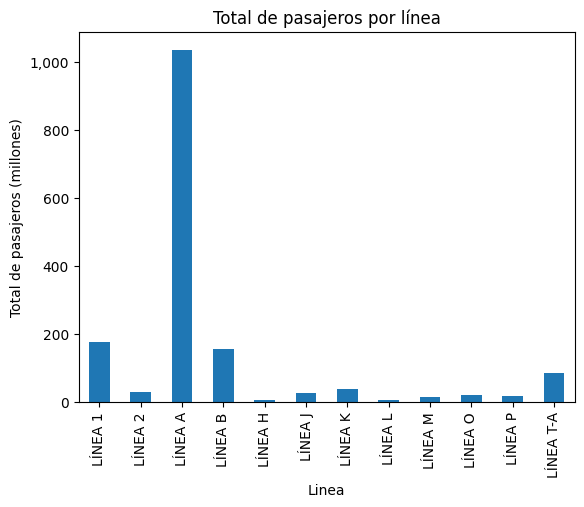

In [ ]:
ax = (df.groupby('Linea')['Total_pasajeros'].sum() / 1e6).plot(kind='bar')
plt.ylabel('Total de pasajeros (millones)')
plt.title('Total de pasajeros por línea')

ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.show()

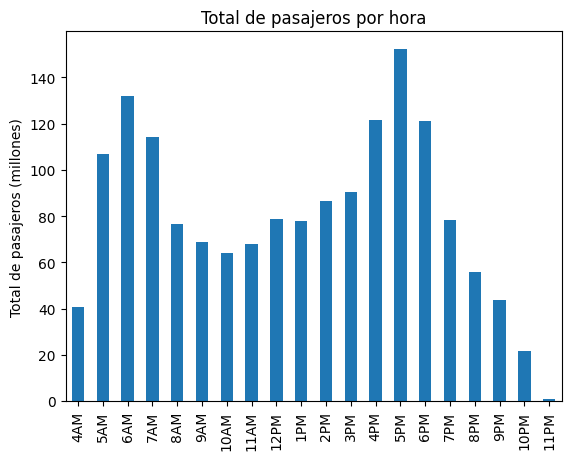

In [ ]:
ax = (df.drop(columns=['Dia','Linea','Total_pasajeros','Festivo','Mes','Year','Dia_semana','Tipo de dia']).sum()/ 1e6).plot(kind='bar')
plt.ylabel('Total de pasajeros (millones)')
plt.title('Total de pasajeros por hora')

ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.show()

In [ ]:
#grafica interactiva
def update_plot(line):
    df_filtered = df[df['Linea'] == line]
    passengers_by_hour = (df_filtered.drop(columns=['Dia', 'Linea', 'Total_pasajeros','Dia','Festivo','Dia_semana','Tipo de dia','Mes','Year']).sum() / 1e6)
    ax = passengers_by_hour.plot(kind='bar', figsize=(10, 5))
    plt.ylabel('Total de pasajeros (millones)')
    plt.title(f'Total de pasajeros por hora en {line}')
    ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    plt.show()

interact(update_plot, line=Dropdown(options=df['Linea'].unique(), value='LÍNEA A', description='Linea:'))

interactive(children=(Dropdown(description='Linea:', index=2, options=('LÍNEA 1', 'LÍNEA 2', 'LÍNEA A', 'LÍNEA…

<function __main__.update_plot(line)>

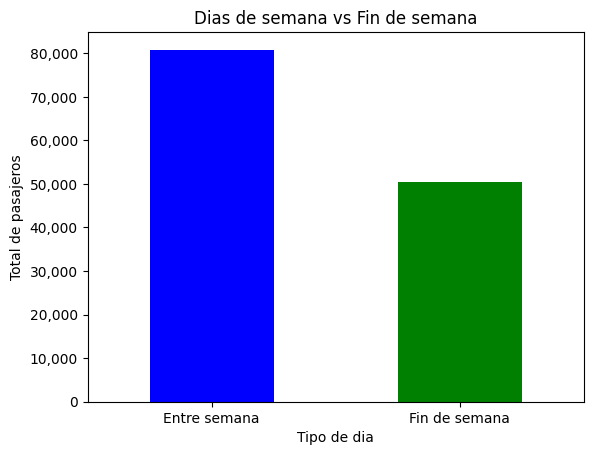

In [ ]:
df['Dia'] = pd.to_datetime(df['Dia'], format='%d/%m/%Y')
passenger_summary = df.groupby('Tipo de dia')['Total_pasajeros'].mean()


ax = passenger_summary.plot(kind='bar', color=['blue', 'green'])
plt.ylabel('Total de pasajeros')
plt.title('Dias de semana vs Fin de semana')
plt.xticks(rotation=0)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.show()
#visualizar en cada linea tambien

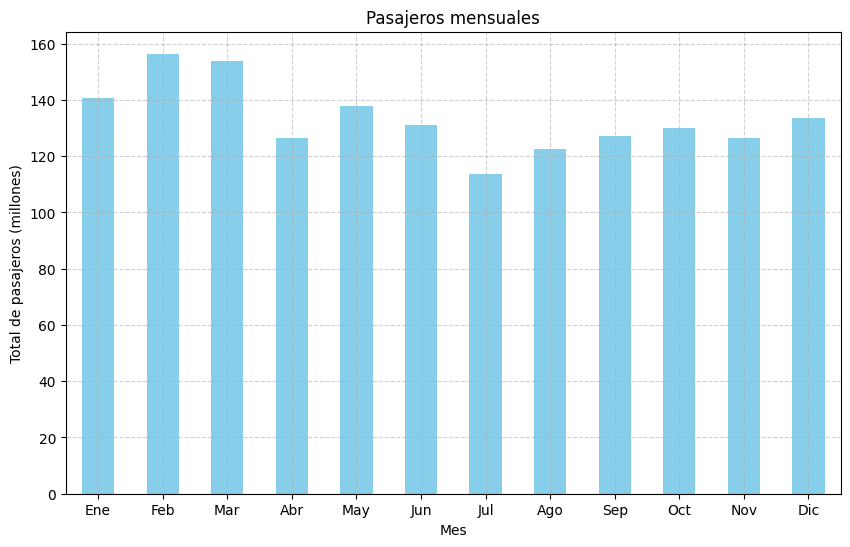

In [ ]:
df['Dia'] = pd.to_datetime(df['Dia'])

#Flujo de pasajeros por mes
monthly_passenger_flow = df.groupby('Mes')['Total_pasajeros'].sum()/1e6

plt.figure(figsize=(10, 6))
monthly_passenger_flow.plot(kind='bar', color='skyblue')
plt.title('Pasajeros mensuales')
plt.xlabel('Mes')
plt.ylabel('Total de pasajeros (millones)')
plt.xticks(ticks=range(len(monthly_passenger_flow)), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'], rotation=0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Datos nulos y cambiar tipo de datos

In [ ]:
df.replace('None', np.nan, inplace=True)

In [ ]:
print(df.isna().sum())

Dia                   0
Linea                 0
4AM                3418
5AM                3276
6AM                3265
7AM                3218
8AM                 927
9AM                 115
10AM                125
11AM                118
12PM                116
1PM                 119
2PM                 121
3PM                 146
4PM                 133
5PM                 124
6PM                1237
7PM                1654
8PM                1645
9PM                1651
10PM               1957
11PM               9665
Total_pasajeros       0
Festivo               0
Dia_semana            0
Tipo de dia           0
Mes                   0
Year                  0
dtype: int64


In [ ]:
print(df.isnull().sum())

Dia                   0
Linea                 0
4AM                3418
5AM                3276
6AM                3265
7AM                3218
8AM                 927
9AM                 115
10AM                125
11AM                118
12PM                116
1PM                 119
2PM                 121
3PM                 146
4PM                 133
5PM                 124
6PM                1237
7PM                1654
8PM                1645
9PM                1651
10PM               1957
11PM               9665
Total_pasajeros       0
Festivo               0
Dia_semana            0
Tipo de dia           0
Mes                   0
Year                  0
dtype: int64


In [ ]:
for col in df.columns[2:22]:
    df[col] = df[col].fillna(df[col].mean())
    df[col] = df[col].astype('int64')
df.info()

<ipython-input-45-5020a62b4c56>:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mean())
<ipython-input-45-5020a62b4c56>:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mean())
<ipython-input-45-5020a62b4c56>:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[co

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22189 entries, 0 to 22188
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Dia              22189 non-null  datetime64[ns]
 1   Linea            22189 non-null  object        
 2   4AM              22189 non-null  int64         
 3   5AM              22189 non-null  int64         
 4   6AM              22189 non-null  int64         
 5   7AM              22189 non-null  int64         
 6   8AM              22189 non-null  int64         
 7   9AM              22189 non-null  int64         
 8   10AM             22189 non-null  int64         
 9   11AM             22189 non-null  int64         
 10  12PM             22189 non-null  int64         
 11  1PM              22189 non-null  int64         
 12  2PM              22189 non-null  int64         
 13  3PM              22189 non-null  int64         
 14  4PM              22189 non-null  int64

<ipython-input-45-5020a62b4c56>:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mean())
<ipython-input-45-5020a62b4c56>:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mean())
<ipython-input-45-5020a62b4c56>:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[co

In [ ]:
df.isnull().sum()

,0
Dia,0
Linea,0
4AM,0
5AM,0
6AM,0
7AM,0
8AM,0
9AM,0
10AM,0
11AM,0


In [ ]:
df['Total_pasajeros'] = pd.to_numeric(df['Total_pasajeros'], errors='coerce')
df['Year'] = df['Year'].astype('category')
df['Tipo de dia'] = df['Tipo de dia'].astype('category')
df['Dia_semana'] = df['Dia_semana'].astype('category')
df['Mes'] = df['Mes'].astype('category')
df['Linea'] = df['Linea'].astype('category')
print(df.dtypes)

Dia                datetime64[ns]
Linea                    category
4AM                         int64
5AM                         int64
6AM                         int64
7AM                         int64
8AM                         int64
9AM                         int64
10AM                        int64
11AM                        int64
12PM                        int64
1PM                         int64
2PM                         int64
3PM                         int64
4PM                         int64
5PM                         int64
6PM                         int64
7PM                         int64
8PM                         int64
9PM                         int64
10PM                        int64
11PM                        int64
Total_pasajeros             int64
Festivo                      bool
Dia_semana               category
Tipo de dia              category
Mes                      category
Year                     category
dtype: object


# Visualización de los datos


<ipython-input-48-482e1ec892e1>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pasajeros_anuales = df.groupby('Year')['Total_pasajeros'].sum()/1e6


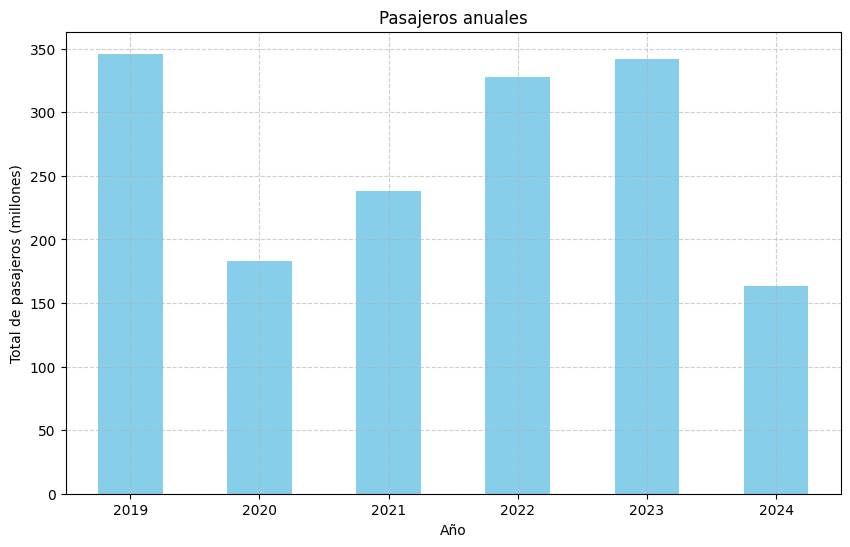

In [ ]:
pasajeros_anuales = df.groupby('Year')['Total_pasajeros'].sum()/1e6

plt.figure(figsize=(10, 6))
pasajeros_anuales.plot(kind='bar', color='skyblue')
plt.title('Pasajeros anuales')
plt.xlabel('Año')
plt.ylabel('Total de pasajeros (millones)')
plt.xticks(ticks=range(len(pasajeros_anuales)), labels=['2019', '2020', '2021', '2022', '2023', '2024'], rotation=0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:

def update_plot(year):
    df_filtered = df[df['Year'] == year]

    monthly_passenger_flow = df_filtered.groupby('Mes')['Total_pasajeros'].sum() / 1e6

    ax = monthly_passenger_flow.plot(kind='bar', figsize=(10, 5), title=f'Total de pasajeros por mes en {year}')
    plt.ylabel('Total de pasajeros (millones)')
    ax.get_yaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))
    plt.xticks(ticks=range(len(monthly_passenger_flow)), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'], rotation=0)
    plt.show()

year_options = df['Year'].unique()
default_year = year_options[0] if len(year_options) > 0 else None

interact(update_plot, year=Dropdown(options=year_options, value=default_year, description='Year:'))


interactive(children=(Dropdown(description='Year:', options=(2019, 2020, 2021, 2022, 2023, 2024), value=2019),…

<function __main__.update_plot(year)>

In [ ]:
import plotly.express as px

fig = px.scatter(df, x='Dia', y='Total_pasajeros', hover_data=['Dia_semana'])
fig.show()

FALTA VISUALIZARLO EN CADA LÍNEA DEL METRO

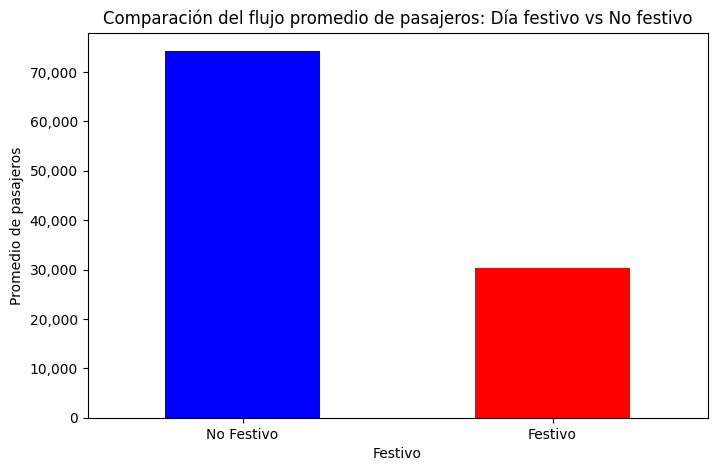

In [ ]:
passenger_summary = df.groupby('Festivo')['Total_pasajeros'].mean()

ax = passenger_summary.plot(kind='bar', color=['blue', 'red'], figsize=(8, 5))
plt.ylabel('Promedio de pasajeros')
plt.title('Comparación del flujo promedio de pasajeros: Día festivo vs No festivo')
plt.xticks([0, 1], ['No Festivo', 'Festivo'], rotation=0)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.show() #visualizarlo en cada linea tambien

# Detección de outliers y duplicados

In [ ]:
def find_outliers_IQR(df, start_col, end_col):
    columns = df.loc[:, start_col:end_col].columns
    outliers_dict = {}

    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        IQR = q3 - q1
        outliers = df[(df[col] < (q1 - 1.5 * IQR)) | (df[col] > (q3 + 1.5 * IQR))]
        outliers_dict[col] = outliers

    return outliers_dict

outliers_dict = find_outliers_IQR(df, '4AM', '11PM')

# Imprimir cantidad de outliers por cada hora
for hour, data in outliers_dict.items():
    print(f'Hora: {hour}, Cantidad de outliers: {len(data)}')

Hora: 4AM, Cantidad de outliers: 1605
Hora: 5AM, Cantidad de outliers: 1602
Hora: 6AM, Cantidad de outliers: 1584
Hora: 7AM, Cantidad de outliers: 1573
Hora: 8AM, Cantidad de outliers: 1831
Hora: 9AM, Cantidad de outliers: 2137
Hora: 10AM, Cantidad de outliers: 1912
Hora: 11AM, Cantidad de outliers: 1920
Hora: 12PM, Cantidad de outliers: 1978
Hora: 1PM, Cantidad de outliers: 2138
Hora: 2PM, Cantidad de outliers: 2036
Hora: 3PM, Cantidad de outliers: 1950
Hora: 4PM, Cantidad de outliers: 2035
Hora: 5PM, Cantidad de outliers: 2423
Hora: 6PM, Cantidad de outliers: 1871
Hora: 7PM, Cantidad de outliers: 1883
Hora: 8PM, Cantidad de outliers: 1871
Hora: 9PM, Cantidad de outliers: 1890
Hora: 10PM, Cantidad de outliers: 1589
Hora: 11PM, Cantidad de outliers: 396


In [ ]:
def find_column_outliers_IQR(df, columns):
    outliers = pd.DataFrame(index=df.index)

    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        IQR = q3 - q1
        outliers[col] = (df[col] < (q1 - 1.5 * IQR)) | (df[col] > (q3 + 1.5 * IQR))

    return outliers

hour_columns = df.loc[:, '4AM':'11PM'].columns
column_outliers = find_column_outliers_IQR(df, hour_columns)

# Print number of outliers per column
for col in hour_columns:
    print(f'Column: {col}, Number of outliers: {column_outliers[col].sum()}')

Column: 4AM, Number of outliers: 1605
Column: 5AM, Number of outliers: 1602
Column: 6AM, Number of outliers: 1584
Column: 7AM, Number of outliers: 1573
Column: 8AM, Number of outliers: 1831
Column: 9AM, Number of outliers: 2137
Column: 10AM, Number of outliers: 1912
Column: 11AM, Number of outliers: 1920
Column: 12PM, Number of outliers: 1978
Column: 1PM, Number of outliers: 2138
Column: 2PM, Number of outliers: 2036
Column: 3PM, Number of outliers: 1950
Column: 4PM, Number of outliers: 2035
Column: 5PM, Number of outliers: 2423
Column: 6PM, Number of outliers: 1871
Column: 7PM, Number of outliers: 1883
Column: 8PM, Number of outliers: 1871
Column: 9PM, Number of outliers: 1890
Column: 10PM, Number of outliers: 1589
Column: 11PM, Number of outliers: 396


In [ ]:
row_outliers = pd.DataFrame(index=df.index)
for col in hour_columns:
    row_outliers[col] = df.index.isin(outliers_dict[col].index)

combined_outliers = pd.DataFrame(index=df.index)
for col in hour_columns:
    combined_outliers[col] = row_outliers[col] & column_outliers[col]

# Count the number of combined outliers for each hour column
combined_outliers_summary = combined_outliers.sum()
print(combined_outliers_summary)


4AM     1605
5AM     1602
6AM     1584
7AM     1573
8AM     1831
9AM     2137
10AM    1912
11AM    1920
12PM    1978
1PM     2138
2PM     2036
3PM     1950
4PM     2035
5PM     2423
6PM     1871
7PM     1883
8PM     1871
9PM     1890
10PM    1589
11PM     396
dtype: int64


In [ ]:
# Identify rows with any common outliers
common_outliers = combined_outliers.any(axis=1)

# Extract and display rows that are common outliers
common_outliers_df = df[common_outliers]
common_outliers_df.sample(10)

,Dia,Linea,4AM,5AM,6AM,7AM,8AM,9AM,10AM,11AM,...,8PM,9PM,10PM,11PM,Total_pasajeros,Festivo,Dia_semana,Tipo de dia,Mes,Year
16478,2023-03-04,LÍNEA 1,2192,5138,6552,7513,5161,4672,4580,5021,...,3137,2563,1691,78,93654,False,5,Fin de semana,3,2023
13226,2022-05-31,LÍNEA B,3047,8087,9025,8394,5254,4454,3854,4128,...,3000,2239,5738,21,104547,False,1,Entre semana,5,2022
10239,2021-09-20,LÍNEA A,14091,39417,50377,38989,24954,20875,19144,19639,...,15185,11411,6234,28,550560,False,0,Entre semana,9,2021
270,2019-09-28,LÍNEA 1,2226,5818,7546,8291,5794,5157,4828,5456,...,3510,3210,2214,169,104744,False,5,Fin de semana,9,2019
777,2019-02-17,LÍNEA A,2896,9831,12073,12827,13530,14874,17153,17695,...,18531,13620,1132,69,311465,False,6,Fin de semana,2,2019
3565,2020-01-01,LÍNEA A,1,4901,6168,4822,4158,5152,6467,8488,...,16450,10701,1177,69,192714,True,2,Entre semana,1,2020
3447,2019-09-07,LÍNEA T-A,916,2573,3369,3636,2624,2305,2393,2600,...,2025,1863,1793,617,50756,False,5,Fin de semana,9,2019
811,2019-03-23,LÍNEA A,11065,30839,37781,38799,27045,24773,24666,28390,...,19178,18002,11354,182,580016,False,5,Fin de semana,3,2019
5243,2020-06-10,LÍNEA A,10228,19920,22001,17153,10868,8491,7022,6975,...,5730,5656,643,69,231884,False,2,Entre semana,6,2020
13634,2022-07-06,LÍNEA A,16385,44599,58071,48801,30576,25783,24096,23996,...,19966,15706,8646,43,660718,False,2,Entre semana,7,2022


In [ ]:
#Numero total de festivos y dias no festivos
total_holidays = df['Festivo'].sum()
total_non_holidays = len(df) - total_holidays

# numero total de dias fin de semana y dias de semana
total_weekends = df[df['Tipo de dia'] == 'Fin de semana'].shape[0]
total_weekdays = len(df) - total_weekends

# Relacion de outliers con fin de semana y festivos con datos normalizados
for hour, outliers in outliers_dict.items():
    total_outliers = len(outliers)
    holiday_outliers = outliers['Festivo'].sum()
    weekend_outliers = outliers[outliers['Tipo de dia'] == 'Fin de semana'].shape[0]

    holiday_proportion = holiday_outliers / total_holidays if total_holidays != 0 else 0
    non_holiday_proportion = (total_outliers - holiday_outliers) / total_non_holidays if total_non_holidays != 0 else 0

    weekend_proportion = weekend_outliers / total_weekends if total_weekends != 0 else 0
    weekday_proportion = (total_outliers - weekend_outliers) / total_weekdays if total_weekdays != 0 else 0

    print(f'Hora: {hour}')
    print(f'  Total outliers: {total_outliers}')
    print(f'  Outliers on holidays: {holiday_outliers} ({holiday_proportion * 100:.2f}%)')
    print(f'  Outliers on non-holidays: {total_outliers - holiday_outliers} ({non_holiday_proportion * 100:.2f}%)')
    print(f'  Outliers on weekends: {weekend_outliers} ({weekend_proportion * 100:.2f}%)')
    print(f'  Outliers on weekdays: {total_outliers - weekend_outliers} ({weekday_proportion * 100:.2f}%)\n')


Hora: 4AM
  Total outliers: 1605
  Outliers on holidays: 2 (0.18%)
  Outliers on non-holidays: 1603 (7.60%)
  Outliers on weekends: 273 (4.28%)
  Outliers on weekdays: 1332 (8.42%)

Hora: 5AM
  Total outliers: 1602
  Outliers on holidays: 10 (0.92%)
  Outliers on non-holidays: 1592 (7.54%)
  Outliers on weekends: 270 (4.24%)
  Outliers on weekdays: 1332 (8.42%)

Hora: 6AM
  Total outliers: 1584
  Outliers on holidays: 7 (0.65%)
  Outliers on non-holidays: 1577 (7.47%)
  Outliers on weekends: 261 (4.10%)
  Outliers on weekdays: 1323 (8.36%)

Hora: 7AM
  Total outliers: 1573
  Outliers on holidays: 6 (0.55%)
  Outliers on non-holidays: 1567 (7.43%)
  Outliers on weekends: 265 (4.16%)
  Outliers on weekdays: 1308 (8.27%)

Hora: 8AM
  Total outliers: 1831
  Outliers on holidays: 51 (4.70%)
  Outliers on non-holidays: 1780 (8.43%)
  Outliers on weekends: 477 (7.48%)
  Outliers on weekdays: 1354 (8.56%)

Hora: 9AM
  Total outliers: 2137
  Outliers on holidays: 75 (6.91%)
  Outliers on non-ho

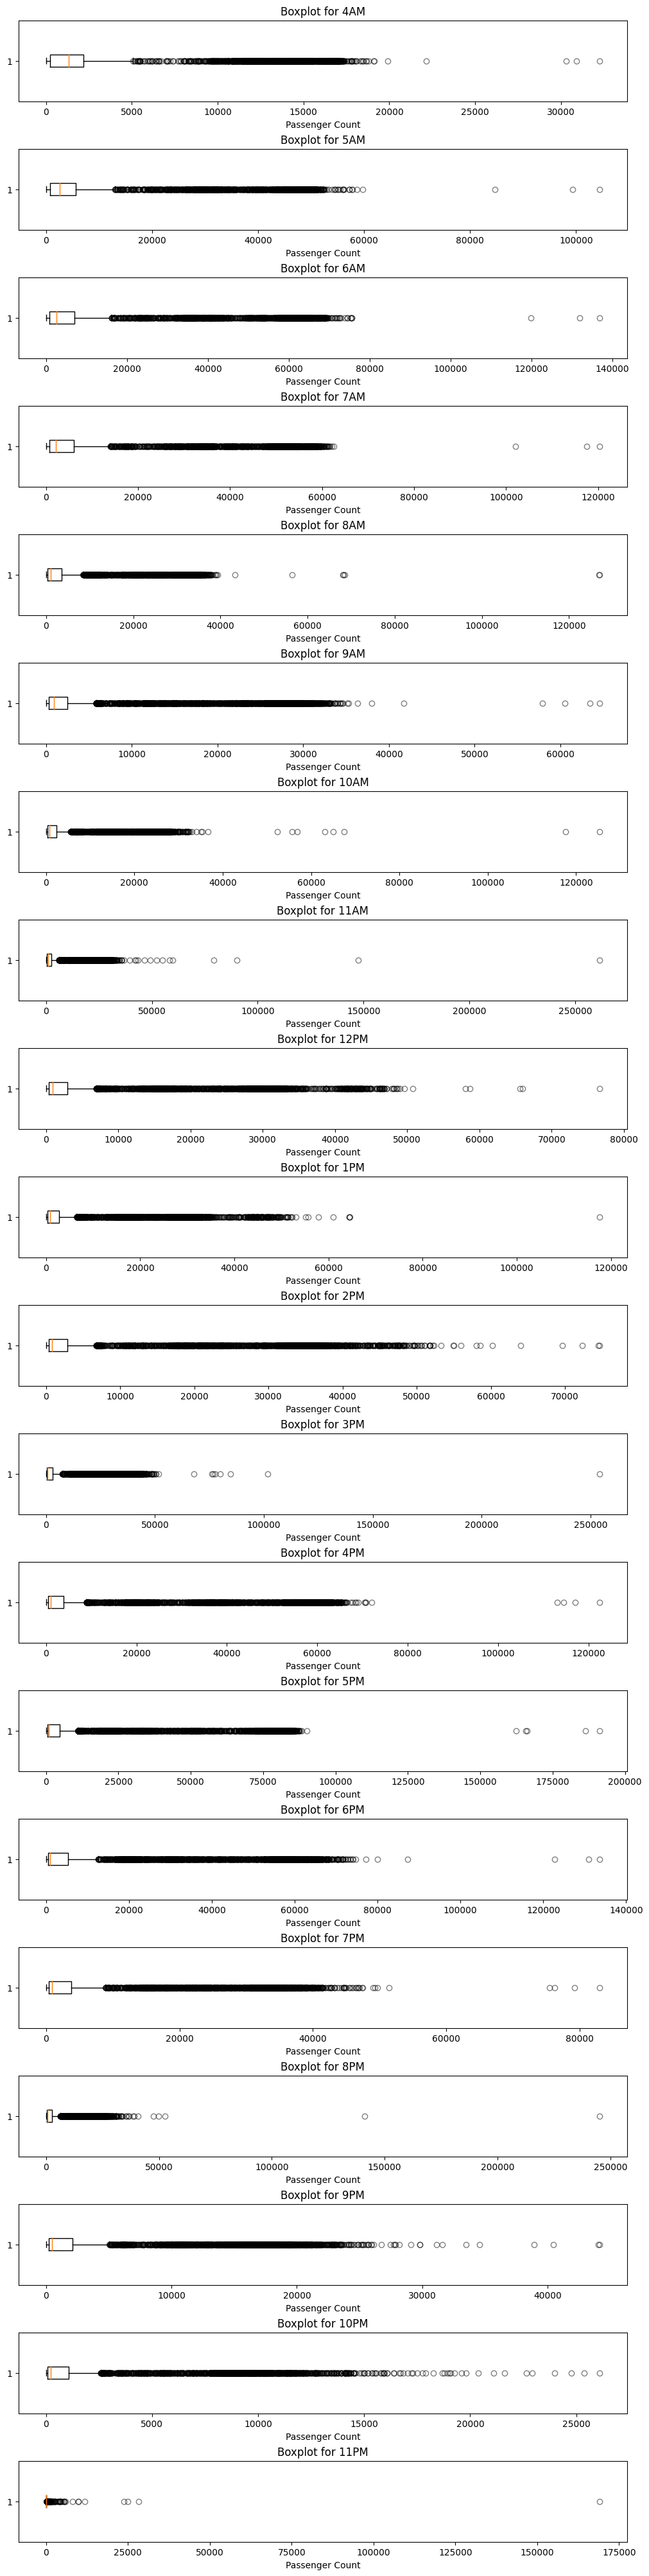

In [ ]:
def plot_outliers_boxplots(df, start_col, end_col):
    columns = df.loc[:, start_col:end_col].columns
    num_columns = len(columns)
    fig, axs = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, num_columns*2), constrained_layout=True)

    for i, col in enumerate(columns):
        axs[i].boxplot(df[col].dropna(), vert=False, flierprops=dict(marker='o', color='red', alpha=0.5))
        axs[i].set_title(f'Boxplot for {col}')
        axs[i].set_xlabel('Passenger Count')

    plt.show()

plot_outliers_boxplots(df, '4AM', '11PM')

# Detección de anomalías

In [ ]:
#Solo columnas de horas
data = df.loc[:, '4AM':'11PM']

# modelo de IsolationForest para deteccion de anomalias
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(data)

df['anomaly'] = model.predict(data)

anomalies = df[df['anomaly'] == -1]
print(f'Total anomalies detected: {len(anomalies)}')

Total anomalies detected: 1110


In [ ]:
non_anomalies = df[df['anomaly'] != -1]

In [ ]:
# Relacion entre festivos y dia de semana en anomalias
holiday_anomalies = anomalies[anomalies['Festivo'] == True]
weekend_anomalies = anomalies[anomalies['Tipo de dia'] == 'Weekend']

print(f'Total anomalies: {len(anomalies)}')
print(f'Holiday anomalies: {len(holiday_anomalies)} ({len(holiday_anomalies) / len(anomalies) * 100:.2f}%)')
print(f'Weekend anomalies: {len(weekend_anomalies)} ({len(weekend_anomalies) / len(anomalies) * 100:.2f}%)')

Total anomalies: 1110
Holiday anomalies: 26 (2.34%)
Weekend anomalies: 0 (0.00%)


# Imputación de anomalías y outliers

In [ ]:

hour_columns = df.loc[:, '4AM':'11PM'].columns
non_anomalies = df[df['anomaly'] == 0].copy()
anomalies = df[df['anomaly'] == 1].copy()

imputer = KNNImputer(n_neighbors=5)

df[hour_columns] = imputer.fit_transform(df[hour_columns])

df.drop(columns=['anomaly'], inplace=True)

df.head()

,Dia,Linea,4AM,5AM,6AM,7AM,8AM,9AM,10AM,11AM,...,8PM,9PM,10PM,11PM,Total_pasajeros,Festivo,Dia_semana,Tipo de dia,Mes,Year
0,2019-01-01,LÍNEA 1,12.0,826.0,1134.0,987.0,884.0,975.0,1259.0,1348.0,...,2024.0,1257.0,271.0,5.0,28850,True,1,Entre semana,1,2019
1,2019-01-02,LÍNEA 1,1716.0,4498.0,6629.0,6284.0,4145.0,3784.0,3746.0,3854.0,...,2975.0,2709.0,1890.0,135.0,83484,False,2,Entre semana,1,2019
2,2019-01-03,LÍNEA 1,1860.0,4869.0,7587.0,7088.0,4483.0,4486.0,4126.0,4136.0,...,3244.0,2905.0,1739.0,124.0,90472,False,3,Entre semana,1,2019
3,2019-01-04,LÍNEA 1,1845.0,4989.0,7723.0,7281.0,4857.0,4583.0,4269.0,4217.0,...,3466.0,3075.0,1900.0,176.0,93067,False,4,Entre semana,1,2019
4,2019-01-05,LÍNEA 1,1550.0,3852.0,4898.0,5221.0,4016.0,3815.0,3704.0,4048.0,...,2973.0,2866.0,1983.0,167.0,75451,False,5,Fin de semana,1,2019


In [ ]:
# Imputacion de anomalias usando KNNimputer
imputer = KNNImputer(n_neighbors=5)
imputed_data = df[hour_columns].copy()
imputed_data.loc[df['anomaly'] == 1, hour_columns] = imputer.fit_transform(df[hour_columns].loc[df['anomaly'] == 1])

# Reemplazar el dataframe original por los imputados
df[hour_columns] = imputed_data

# Borramos la columna de anomalia
df.drop(columns=['anomaly'], inplace=True)

print(df.head())

KeyError: 'anomaly'

#Manejo de filas duplicadas

In [ ]:
duplicated_rows = df[df.duplicated()]

print(duplicated_rows)

No hay filas duplicadas en el dataframe

#ANOVA (Analysis of variances) y ANOM (Analysis of means)

In [ ]:
from scipy.stats import f_oneway
df = df[df['Year'] != 2024]

annual_data = df.groupby(['Year', 'Linea'])['Total_pasajeros'].mean().reset_index()

In [ ]:
# Perform ANOVA for each line separately
unique_lines = annual_data['Linea'].unique()

anova_results = {}
for line in unique_lines:
    data_by_line = annual_data[annual_data['Linea'] == line]
    # Collect data for each year
    data_2019 = data_by_line[data_by_line['Year'] == 2019]['Total_pasajeros']
    data_2020 = data_by_line[data_by_line['Year'] == 2020]['Total_pasajeros']
    data_2021 = data_by_line[data_by_line['Year'] == 2021]['Total_pasajeros']
    data_2022 = data_by_line[data_by_line['Year'] == 2022]['Total_pasajeros']
    data_2023 = data_by_line[data_by_line['Year'] == 2023]['Total_pasajeros']

    # Perform ANOVA
    f_val, p_val = f_oneway(data_2019, data_2020, data_2021, data_2022, data_2023)
    anova_results[line] = (f_val, p_val)

# Output the results
for line, results in anova_results.items():
    print(f"Line {line}: F-value = {results[0]}, P-value = {results[1]}")


In [ ]:
model = ols('Total_pasajeros ~ C(Year)', data=df).fit()
anova_results = sm.stats.anova_lm(model, typ=2)

anova_df = pd.DataFrame(anova_results)

formatted_anova = anova_df.style.format({
    'sum_sq': "{:,.2f}",
    'df': "{:.0f}",
    'F': "{:.2f}",
    'PR(>F)': "{:.4f}"
}).set_caption("ANOVA Table").set_table_styles([{
    'selector': 'caption',
    'props': [('color', 'red'), ('font-size', '16px')]
}])

formatted_anova

In [ ]:
def interpret_anova_results(anova_table):
    p_value = anova_table.loc['C(Year)', 'PR(>F)']
    alpha = 0.05  #Nivel de significancia

    print("\nANOVA Results Interpretation:")
    if p_value < alpha:
        print(f"The p-value ({p_value:.4f}) is less than the significance level ({alpha}), suggesting that there is a statistically significant difference in 'Total_pasajeros' across different 'Year'.")
        print("We reject the null hypothesis that there is no year-to-year variation in total passengers.")
    else:
        print(f"The p-value ({p_value:.4f}) is greater than the significance level ({alpha}), suggesting that there is no statistically significant difference in 'Total_pasajeros' across different 'Year'.")
        print("We fail to reject the null hypothesis that there is no year-to-year variation in total passengers.")

interpret_anova_results(anova_results)


In [ ]:

# Normality test using Shapiro-Wilk Test
_, pval_normality = shapiro(model.resid)
print("Normality test p-value =", pval_normality)

In [ ]:
# Homoscedasticity test using Levene's Test
_, pval_homoscedasticity = levene(df['Total_pasajeros'][df['Year'] == 2019],
                                  df['Total_pasajeros'][df['Year'] == 2020],
                                  df['Total_pasajeros'][df['Year'] == 2021],
                                  df['Total_pasajeros'][df['Year'] == 2022],
                                  df['Total_pasajeros'][df['Year'] == 2023],
                                  df['Total_pasajeros'][df['Year'] == 2024])
print("Homoscedasticity test p-value =", pval_homoscedasticity)


In [ ]:
# Filtrar solo las líneas 1, 2, A, y B
filtered_values = ['LÍNEA 1', 'LÍNEA 2', 'LÍNEA A', 'LÍNEA B']
df_filtered = df[df['Linea'].isin(filtered_values)]

# Agrupar los datos por 'Linea' y 'Year' y sumar 'Total Pasajeros'
df_grouped = df_filtered.groupby(['Linea', 'Year'])['Total_pasajeros'].sum().reset_index()

# Crear el gráfico de líneas con una mejor escala en el eje Y
plt.figure(figsize=(12, 8))

for linea in filtered_values:
    df_linea = df_grouped[df_grouped['Linea'] == linea]
    plt.plot(df_linea['Year'], df_linea['Total_pasajeros'], marker='o', linestyle='-', label=linea)

plt.title('Total de Pasajeros por Año para Líneas 1, 2, A y B')
plt.xlabel('Año')
plt.ylabel('Total Pasajeros')
plt.grid(True)
plt.legend()
plt.xticks(df_grouped['Year'].unique())  # Asegura que solo se muestren años completos en el eje x

# Ajustar los límites del eje Y para una mejor visualización
plt.ylim(0, 0.5e8)  # Ajustar según sea necesario

plt.show()

#Preprocesamiento de datos



1.   Creación de lagged features
2.   Normalización de los datos
3.   División de datos de entrenamiento y datos de prueba.



In [ ]:
rows = []
for _, row in df.iterrows():
    for hour in range(4, 24):  # from 4AM to 11PM
        hour_col = f'{hour % 12 if hour % 12 != 0 else 12}{"AM" if hour < 12 else "PM"}'
        rows.append({
            'Dia': row['Dia'],
            'Linea': row['Linea'],
            'Hour': hour_col,
            'Passengers': row[hour_col],
            'Festivo': row['Festivo'],
            'Dia_semana': row['Dia_semana'],
            'Tipo de dia': row['Tipo de dia'],
            'Mes': row['Mes']
        })

restructured_df = pd.DataFrame(rows)
restructured_df.head()

In [ ]:
# Definimos numero de lags
n_lags = 7  # Creamos features por los 7 dias pasados

# Crecion de lagged features para cada columna de hora
for lag in range(1, n_lags + 1):
    for col in df.loc[:, '4AM':'11PM'].columns:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

# quitamos las filas con NaN dadas por el proceso de laggeado
df = df.dropna()

print(df.head())

In [ ]:
split_date = '2022-12-31'
train_data = df[df['Dia'] <= split_date]
test_data = df[df['Dia'] > split_date]


hour_columns = df.loc[:, '4AM':'11PM'].columns
features = hour_columns
target = 'Total_pasajeros'

scaler = MinMaxScaler()
train_data[features] = scaler.fit_transform(train_data[features])
test_data[features] = scaler.transform(test_data[features])

class TimeSeriesDataset(Dataset):
    def __init__(self, data, features, target):
        self.features = data[features].values
        self.target = data[target].values

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        x = torch.tensor(self.features[idx], dtype=torch.float32)
        y = torch.tensor(self.target[idx], dtype=torch.float32)
        return x, y

train_dataset = TimeSeriesDataset(train_data, features, target)
test_dataset = TimeSeriesDataset(test_data, features, target)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# Creacion de LSTM

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
from sklearn.preprocessing import MinMaxScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#Attention Layer
class YearAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(YearAttention, self).__init__()
        self.attn = nn.Linear(hidden_dim, 1, bias=False)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, lstm_output, years):
        weights = torch.ones(lstm_output.size(0), lstm_output.size(1)).to(lstm_output.device)
        for i, year in enumerate(years):
            if year == 2019:
                weights[i, :] = 2.0  # mas relevancia a 2019
            elif year == 2020:
                weights[i, :] = 0.5  # Mas relevancia a 2020

        attn_weights = self.attn(lstm_output).squeeze(-1)
        attn_weights = attn_weights * weights
        attn_weights = self.softmax(attn_weights)

        context = torch.bmm(attn_weights.unsqueeze(1), lstm_output).squeeze(1)
        return context, attn_weights

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Attention layer
        self.attention = YearAttention(hidden_size)

        self.fc1 = nn.Linear(hidden_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, output_size)

    def forward(self, x, years):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # LSTM forward pass
        out, _ = self.lstm(x, (h0, c0))

        # Attention layer
        context, _ = self.attention(out, years)

        out = self.fc1(context)
        out = torch.relu(out)
        out = self.fc2(out)
        out = torch.relu(out)
        out = self.fc3(out)
        return out

split_date = '2022-12-31'
train_data = df[df['Dia'] <= split_date].copy()
test_data = df[df['Dia'] > split_date].copy()

hour_columns = df.loc[:, '4AM':'11PM'].columns
additional_features = ['Festivo', 'Tipo de dia', 'Mes', 'Year', 'Dia_semana'] + [col for col in df.columns if col.startswith('Linea_')]
features = list(hour_columns) + additional_features
target = 'Total_pasajeros'

print("NaNs before handling:")
print(train_data[features].isna().sum())
print(test_data[features].isna().sum())

train_data[features] = train_data[features].fillna(0)
test_data[features] = test_data[features].fillna(0)

# Scaling features
scaler = MinMaxScaler()
train_data[features] = scaler.fit_transform(train_data[features])
test_data[features] = scaler.transform(test_data[features])

target_scaler = MinMaxScaler()
train_data[target] = target_scaler.fit_transform(train_data[[target]])
test_data[target] = target_scaler.transform(test_data[[target]])

class TimeSeriesDataset(Dataset):
    def __init__(self, data, features, target, year_col='Year'):
        self.features = data[features].values
        self.target = data[target].values
        self.years = data[year_col].values

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        x = torch.tensor(self.features[idx], dtype=torch.float32)
        y = torch.tensor(self.target[idx], dtype=torch.float32).unsqueeze(0)
        year = torch.tensor(self.years[idx], dtype=torch.int64)
        return x, y, year

print(f"Train set length: {len(train_data)}, Test set length: {len(test_data)}")

train_dataset = TimeSeriesDataset(train_data, features, target)
test_dataset = TimeSeriesDataset(test_data, features, target)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

input_size = len(features)
hidden_size = 128
num_layers = 4
output_size = 1

model = LSTMModel(input_size, hidden_size, num_layers, output_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for inputs, targets, years in train_loader:
        inputs = inputs.unsqueeze(1).to(device)
        targets = targets.to(device)
        years = years.to(device)

        outputs = model(inputs, years)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f}')

model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets, years in test_loader:
        inputs = inputs.unsqueeze(1).to(device)
        targets = targets.to(device)
        years = years.to(device)
        outputs = model(inputs, years)
        loss = criterion(outputs, targets)
        test_loss += loss.item()

test_loss /= len(test_loader)
print(f'Test Loss: {test_loss:.4f}')

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

all_predictions = []
all_targets = []

model.eval()
with torch.no_grad():
    for inputs, targets, years in test_loader:
        inputs = inputs.unsqueeze(1).to(device)
        targets = targets.to(device)
        years = years.to(device)
        outputs = model(inputs, years)


        outputs = target_scaler.inverse_transform(outputs.cpu().numpy())
        targets = target_scaler.inverse_transform(targets.cpu().numpy())

        all_predictions.extend(outputs)
        all_targets.extend(targets)

# Calculate MAE and MAPE
mae = mean_absolute_error(all_targets, all_predictions)
mape = mean_absolute_percentage_error(all_targets, all_predictions)

print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}')

# Training

In [ ]:
rows = []
for _, row in df.iterrows():
    for hour in range(4, 24):  # de 4AM a 11PM
        hour_col = f'{hour % 12 if hour % 12 != 0 else 12}{"AM" if hour < 12 else "PM"}'
        rows.append({
            'Dia': row['Dia'],
            'Linea': row['Linea'],
            'Hour': hour_col,
            'Passengers': row[hour_col],
            'Festivo': row['Festivo'],
            'Dia_semana': row['Dia_semana'],
            'Tipo de dia': row['Tipo de dia'],
            'Mes': row['Mes']
        })

restructured_df = pd.DataFrame(rows)

print(restructured_df)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

class TimeSeriesDataset(Dataset):
    def __init__(self, data, features, target, seq_len=18):
        self.features = data[features].values
        self.target = data[target].values
        self.seq_len = seq_len

    def __len__(self):
        return len(self.features) - self.seq_len

    def __getitem__(self, idx):
        x = self.features[idx:idx+self.seq_len]
        y = self.target[idx+self.seq_len]
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)
        return x, y

features = df.columns[2:22]  # 4AM to 11PM columns
additional_features = ['Festivo', 'Dia_semana', 'Tipo de dia', 'Mes']
all_features = list(features) + additional_features
target = 'Total_pasajeros'

scaler = MinMaxScaler()
train_data[all_features] = scaler.fit_transform(train_data[all_features])
test_data[all_features] = scaler.transform(test_data[all_features])

target_scaler = MinMaxScaler()
train_data[[target]] = target_scaler.fit_transform(train_data[[target]])
test_data[[target]] = target_scaler.transform(test_data[[target]])

train_dataset = TimeSeriesDataset(train_data, all_features, target, seq_len=18)
test_dataset = TimeSeriesDataset(test_data, all_features, target, seq_len=18)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class YearAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(YearAttention, self).__init__()
        self.attn = nn.Linear(hidden_dim, 1, bias=False)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, lstm_output, years):
        weights = torch.ones(lstm_output.size(0), lstm_output.size(1)).to(lstm_output.device)
        for i, year in enumerate(years):
            if year == 2019:
                weights[i, :] = 2.0
            elif year == 2020:
                weights[i, :] = 0.5

        attn_weights = self.attn(lstm_output).squeeze(-1)
        attn_weights = attn_weights * weights
        attn_weights = self.softmax(attn_weights)

        context = torch.bmm(attn_weights.unsqueeze(1), lstm_output).squeeze(1)
        return context, attn_weights

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.attention = YearAttention(hidden_size)
        self.fc1 = nn.Linear(hidden_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, output_size)

    def forward(self, x, years):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        context, _ = self.attention(out, years)

        out = self.fc1(context)
        out = torch.relu(out)
        out = self.fc2(out)
        out = torch.relu(out)
        out = self.fc3(out)
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel(input_size=len(all_features), hidden_size=128, num_layers=4, output_size=1).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f}')

model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item()

test_loss /= len(test_loader)
print(f'Test Loss: {test_loss:.4f}')

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

all_predictions = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        outputs = model(inputs)
        outputs = target_scaler.inverse_transform(outputs.cpu().numpy())
        targets = target_scaler.inverse_transform(targets.cpu().numpy())
        all_predictions.extend(outputs)
        all_targets.extend(targets)

mae = mean_absolute_error(all_targets, all_predictions)
mape = mean_absolute_percentage_error(all_targets, all_predictions)
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}')

# Comparacion con otros modelos

In [ ]:
from darts import TimeSeries
from darts.models import RNNModel
from darts.metrics import mape

series = TimeSeries.from_dataframe(data, 'Dia', 'Total_pasajeros')

# Train/Test Split
train, val = series.split_before(pd.Timestamp('2022-01-01'))

# LSTM Model
lstm = RNNModel(model='LSTM', input_chunk_length=24, output_chunk_length=24, n_epochs=100)
lstm.fit(train)
lstm_forecast = lstm.predict(len(val))

lstm_mape = mape(val, lstm_forecast)
print(f'LSTM MAPE: {lstm_mape:.2f}')


# Despliegue

In [ ]:
import pickle

with open('trained_lstm_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset

with open('trained_lstm_model.pkl', 'rb') as f:
    model = pickle.load(f)

date_range = pd.date_range(start='2024-01-01', periods=30, freq='D')
data = {
    'Dia': date_range,
    'Festivo': np.random.randint(0, 2, size=len(date_range)),
    'Dia_semana': date_range.day_name(),
    'Tipo de dia': np.random.randint(0, 2, size=len(date_range)),
    'Mes': date_range.month,
    'Year': date_range.year,
    'Linea_LÍNEA 2': np.random.choice([True, False], size=len(date_range)),
    'Linea_LÍNEA A': np.random.choice([True, False], size=len(date_range)),
    'Linea_LÍNEA B': np.random.choice([True, False], size=len(date_range)),
    'Linea_LÍNEA H': np.random.choice([True, False], size=len(date_range)),
    'Linea_LÍNEA J': np.random.choice([True, False], size=len(date_range)),
    'Linea_LÍNEA K': np.random.choice([True, False], size=len(date_range)),
    'Linea_LÍNEA L': np.random.choice([True, False], size=len(date_range)),
    'Linea_LÍNEA M': np.random.choice([True, False], size=len(date_range)),
    'Linea_LÍNEA O': np.random.choice([True, False], size=len(date_range)),
    'Linea_LÍNEA P': np.random.choice([True, False], size=len(date_range)),
    'Linea_LÍNEA T-A': np.random.choice([True, False], size=len(date_range)),
}
new_data = pd.DataFrame(data)
new_data['Dia_semana'] = new_data['Dia_semana'].astype('category')
new_data['Mes'] = new_data['Mes'].astype('category')
new_data['Year'] = new_data['Year'].astype('category')

features = ['Festivo', 'Dia_semana', 'Tipo de dia', 'Mes', 'Year'] + [col for col in new_data.columns if col.startswith('Linea_')]

scaler = MinMaxScaler()
new_data[features] = scaler.fit_transform(new_data[features])

class TimeSeriesDataset(Dataset):
    def __init__(self, data, features, year_col='Year'):
        self.features = data[features].values
        self.years = data[year_col].values

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        x = torch.tensor(self.features[idx], dtype=torch.float32)
        year = torch.tensor(self.years[idx], dtype=torch.int64)
        return x, year

new_dataset = TimeSeriesDataset(new_data, features)
new_loader = DataLoader(new_dataset, batch_size=16, shuffle=False)

all_predictions = []
model.eval()
with torch.no_grad():
    for inputs, years in new_loader:
        inputs = inputs.unsqueeze(1).to(device)
        years = years.to(device)
        outputs = model(inputs, years)
        outputs = outputs.cpu().numpy()
        all_predictions.extend(outputs)

new_data['Predicted_Total_pasajeros'] = all_predictions

new_data.to_csv('new_data_with_predictions.csv', index=False)

print(new_data[['Dia', 'Predicted_Total_pasajeros']].head())